# **D1.2 - Data preprocessing and ML techniques application to imbalanced data**

## **Drive Authentication & Dataset Loading**

In [1]:
import pandas as pd
df = pd.read_csv('../data/ccr.csv')
df.head()

,Rating Agency,Corporation,Rating,Rating Date,CIK,Binary Rating,SIC Code,Sector,Ticker,Current Ratio,...,EBITDA Margin,Pre-Tax Profit Margin,Net Profit Margin,Asset Turnover,ROE - Return On Equity,Return On Tangible Equity,ROA - Return On Assets,ROI - Return On Investment,Operating Cash Flow Per Share,Free Cash Flow Per Share
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,1056903,1,4941.0,Utils,AWR,1.1507,...,28.9834,13.6093,8.3224,0.3173,8.1724,8.1978,2.6385,4.4530,1.9957,-0.1333
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,8670,1,7374.0,BusEq,ADP,1.1129,...,23.9379,20.8699,13.5690,0.3324,22.0354,47.2858,4.4944,21.8765,0.2501,0.3132
2,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,8858,1,5065.0,Shops,AVT,1.9276,...,3.6338,3.0536,2.1418,2.4620,13.6376,16.7991,5.2731,9.6494,-7.6079,-7.3231
3,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,1035201,1,4941.0,Utils,CWT,0.8358,...,27.9377,15.1135,9.0246,0.2946,9.6412,9.7015,2.6583,5.1018,1.7438,-0.8999
4,Standard & Poor's Ratings Services,Cardinal Health Inc.,A,2010-07-14,721371,1,5122.0,Shops,CAH,1.2931,...,1.5847,1.2304,0.6518,4.9276,11.1256,19.4184,2.9364,8.1844,1.9725,2.4174


In [2]:
df.columns

Index(['Rating Agency', 'Corporation', 'Rating', 'Rating Date', 'CIK',
       'Binary Rating', 'SIC Code', 'Sector', 'Ticker', 'Current Ratio',
       'Long-term Debt / Capital', 'Debt/Equity Ratio', 'Gross Margin',
       'Operating Margin', 'EBIT Margin', 'EBITDA Margin',
       'Pre-Tax Profit Margin', 'Net Profit Margin', 'Asset Turnover',
       'ROE - Return On Equity', 'Return On Tangible Equity',
       'ROA - Return On Assets', 'ROI - Return On Investment',
       'Operating Cash Flow Per Share', 'Free Cash Flow Per Share'],
      dtype='str')

## **1. Data Preprocessing**
*   Detail your approach to encoding categorical variables, normalizing, and
standardizing the data.
*   Analysis of the missing data within your dataset and used data imputation strategies (if used).

### 1.1 Data normalization, standardization and encoding

In [3]:
df.info()
df.select_dtypes(include='object').head()

<class 'pandas.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rating Agency                  7805 non-null   str    
 1   Corporation                    7805 non-null   str    
 2   Rating                         7805 non-null   str    
 3   Rating Date                    7805 non-null   str    
 4   CIK                            7805 non-null   int64  
 5   Binary Rating                  7805 non-null   int64  
 6   SIC Code                       7805 non-null   float64
 7   Sector                         7805 non-null   str    
 8   Ticker                         7805 non-null   str    
 9   Current Ratio                  7805 non-null   float64
 10  Long-term Debt / Capital       7805 non-null   float64
 11  Debt/Equity Ratio              7805 non-null   float64
 12  Gross Margin                   7805 non-null   float64
 13 

C:\Users\diego\AppData\Local\Temp\ipykernel_14928\2121662212.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').head()


,Rating Agency,Corporation,Rating,Rating Date,Sector,Ticker
0,Standard & Poor's Ratings Services,American States Water Co.,A-,2010-07-30,Utils,AWR
1,Standard & Poor's Ratings Services,Automatic Data Processing Inc.,AAA,2010-09-16,BusEq,ADP
2,Standard & Poor's Ratings Services,Avnet Inc.,BBB-,2010-11-23,Shops,AVT
3,Standard & Poor's Ratings Services,California Water Service Co.,AA-,2010-06-29,Utils,CWT
4,Standard & Poor's Ratings Services,Cardinal Health Inc.,A,2010-07-14,Shops,CAH


As there are 3 data types we will first focus on encoding categorical variables, including the dependent variable. In this case, as we are not sure how much information will 'Corporation' provide by encoding it with normal label encoders we will try to compare results with word embeddings. Besides, as the ticker is implicitly included in the corporation we will remove it dimensionality reduction.

In [4]:
df.select_dtypes(include='object').info(verbose=True)
df.select_dtypes(include='object').agg(['dtype', 'nunique']).head().T

<class 'pandas.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Rating Agency  7805 non-null   str  
 1   Corporation    7805 non-null   str  
 2   Rating         7805 non-null   str  
 3   Rating Date    7805 non-null   str  
 4   Sector         7805 non-null   str  
 5   Ticker         7805 non-null   str  
dtypes: str(6)
memory usage: 366.0 KB


C:\Users\diego\AppData\Local\Temp\ipykernel_14928\2178181414.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').info(verbose=True)
C:\Users\diego\AppData\Local\Temp\ipykernel_14928\2178181414.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/m

,dtype,nunique
Rating Agency,str,7
Corporation,str,1377
Rating,str,23
Rating Date,str,1414
Sector,str,12
Ticker,str,678


We load the sentence transformer in order to compute embeddings. We chose the all-MiniLM-L6-v2 BERT based model due to its contextual nature and also, as the sentences that are being converted in embeddings are really short, we selected this reduced version.

In [5]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used: {device}")
model = SentenceTransformer('all-MiniLM-L6-v2').to(device=device)
print(f"Device: {model.device}")

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multiclass-Corporate-Credit-Rating\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device used: cpu


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2925.69it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cpu


In [6]:
import torch
print("torch:", torch.__version__)
print("cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cpu
cuda build: None
cuda available: False
gpu count: 0


Dimensionality reduction so we don't have crazy dataframes and to also avoid overfitting. If this idea of the embeddings becomes a problem we will do further feature engineering.

In [7]:
import umap

embeddings = model.encode(df['Corporation'].unique())

umap_reducer = umap.UMAP(
    n_neighbors=5,
    min_dist=0.1,
    n_components=10,
    metric="cosine",
    random_state=42
)

embeddings_reduced = umap_reducer.fit_transform(embeddings)
print(embeddings_reduced)

c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multiclass-Corporate-Credit-Rating\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[[ 9.741966   1.8634237  5.560016  ...  8.90572    4.3910484  1.6467738]
 [11.216569   4.4588     5.4222546 ...  4.8201857  5.351598   6.465053 ]
 [ 9.67274    3.6276853  5.6080227 ...  5.9247212  6.4321227  6.848755 ]
 ...
 [ 8.90417    2.9447324  5.315035  ...  6.150249   7.076586   7.0508285]
 [ 8.358027   3.6407945  5.2523212 ...  5.631318   7.0091515  7.9281616]
 [10.815774   3.406131   5.3732963 ...  9.031148   6.7541285  5.797031 ]]


Create the dataframe with the embeddings.

In [8]:
unique_corporations = df['Corporation'].unique()
corp_embedding = {corp: embedding for corp, embedding in zip(unique_corporations, embeddings_reduced)}

# We will create 10 new columns (e0 to e9) by mapping each corporation in df to its corresponding embedding
embedding_columns_data = df['Corporation'].apply(lambda x: corp_embedding[x])
df_embeddings = pd.DataFrame(embedding_columns_data.tolist(), index=df.index, columns=[f'e{i}' for i in range(10)])

# Now we drop the original columns and concatenate the new embedding columns
df_emb = df.drop(columns=['Ticker', 'Corporation', 'CIK', 'Rating Date']).copy()
df_emb = pd.concat([df_emb, df_embeddings], axis=1)
df_emb.info()

<class 'pandas.DataFrame'>
RangeIndex: 7805 entries, 0 to 7804
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rating Agency                  7805 non-null   str    
 1   Rating                         7805 non-null   str    
 2   Binary Rating                  7805 non-null   int64  
 3   SIC Code                       7805 non-null   float64
 4   Sector                         7805 non-null   str    
 5   Current Ratio                  7805 non-null   float64
 6   Long-term Debt / Capital       7805 non-null   float64
 7   Debt/Equity Ratio              7805 non-null   float64
 8   Gross Margin                   7805 non-null   float64
 9   Operating Margin               7805 non-null   float64
 10  EBIT Margin                    7805 non-null   float64
 11  EBITDA Margin                  7805 non-null   float64
 12  Pre-Tax Profit Margin          7805 non-null   float64
 13 

Here we will convert the categorical features into numerical by different simple encoding methods. The fact that we used an OrdinalEncoder just shows that the Ratings have some kind of positive or negative implicit meaning.

In [9]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

le = LabelEncoder()
oe = OrdinalEncoder(categories=[['D', 'C', 'CC', 'CC+', 'CCC-', 'CCC', 'CCC+', 'B-', 'B', 'B+',
                                 'BB-', 'BB', 'BB+', 'BBB-', 'BBB', 'BBB+', 'A-', 'A', 'A+',
                                 'AA-', 'AA', 'AA+', 'AAA'
                                ]])
df_cat = pd.DataFrame(df.select_dtypes(include='object').copy()).drop(columns=['Ticker', 'Rating Date', 'Corporation'])
df_cat['Rating Agency'] = le.fit_transform(df['Rating Agency'])
df_cat['Corporation'] = le.fit_transform(df['Corporation'])
df_cat['Sector'] = le.fit_transform(df['Sector'])
df_cat['Rating'] = oe.fit_transform(df[['Rating']])

df_emb = pd.concat([df_emb.drop(columns=['Rating Agency', 'Sector', 'Rating']), df_cat], axis=1).drop(columns=['Corporation'])
df_not_emb = pd.concat([df.drop(columns=['Rating Agency', 'Corporation', 'Sector', 'Rating', 'Ticker', 'Rating Date', 'CIK']), df_cat], axis=1)

C:\Users\diego\AppData\Local\Temp\ipykernel_14928\4213576039.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = pd.DataFrame(df.select_dtypes(include='object').copy()).drop(columns=['Ticker', 'Rating Date', 'Corporation'])


Now we will standardize the data meticulously.

Features that will be scaled:
- 'Current Ratio'
- 'Long-term Debt / Capital'
- 'Debt/Equity Ratio'
- 'Gross Margin'
- 'Operating Margin'
- 'EBIT Margin'
- 'EBITDA Margin'
- 'Pre-Tax Profit Margin'
- 'Net Profit Margin'
- 'Asset Turnover'
- 'ROE - Return On Equity'
- 'Return On Tangible Equity'
- 'ROA - Return On Assets'
- 'ROI - Return On Investment',
- 'Operating Cash Flow Per Share'
- 'Free Cash Flow Per Share'
- 'e0', 'e1',... 'e9'

Features that won't change:
- 'SIC Code'
- 'Binary Rating'
- 'Rating Agency'
- 'Rating'
- 'Sector'
- 'Corporation'

This last variables won't be scaled due to their categorical nature.

Although the components of UMAP are already in a manageable range it can be a good idea to scale them in order for the optimizer to converge faster and so as to not give them more relevance than the rest of variables.

In [10]:
from sklearn.preprocessing import StandardScaler

s_cols = ['Current Ratio',
       'Long-term Debt / Capital', 'Debt/Equity Ratio', 'Gross Margin',
       'Operating Margin', 'EBIT Margin', 'EBITDA Margin',
       'Pre-Tax Profit Margin', 'Net Profit Margin', 'Asset Turnover',
       'ROE - Return On Equity', 'Return On Tangible Equity',
       'ROA - Return On Assets', 'ROI - Return On Investment',
       'Operating Cash Flow Per Share', 'Free Cash Flow Per Share']

e_cols = ['e0', 'e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8', 'e9']

se_cols = s_cols + e_cols

scaler = StandardScaler()
df_emb[se_cols] = scaler.fit_transform(df_emb[se_cols])
df_not_emb[s_cols] = scaler.fit_transform(df_not_emb[s_cols])
print(f" Mean {df_emb['e0'].mean()} and std {df_emb['e0'].std()}")

 Mean 5.453108247537476e-16 and std 1.00006406765551


### 1.2 Missing data analysis
In the case of our dataset, we found no missing instances as stated in the first delivery's overall dataset study. However, if we were to find any missing data, we would probably go for predictive ML methods (such as *random forests* or simple regressions) to try to get the most likely value. However, if we were talking about a considerable amount of missing instances, we would likely switch to a less computationally expensive strategy like introducing the *mean/mode/median* even if this might ignores the relations between variables. Although we dont miss anything, we will print the analysis.

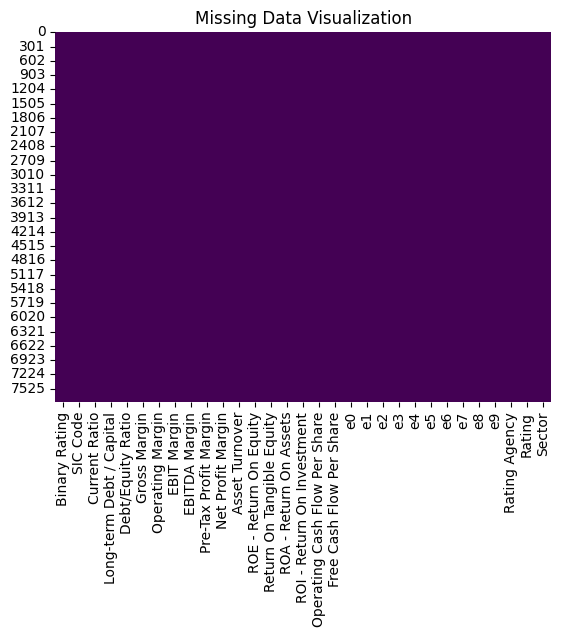

Number of missing instances per variable in our dataset:
Binary Rating                    0
SIC Code                         0
Current Ratio                    0
Long-term Debt / Capital         0
Debt/Equity Ratio                0
Gross Margin                     0
Operating Margin                 0
EBIT Margin                      0
EBITDA Margin                    0
Pre-Tax Profit Margin            0
Net Profit Margin                0
Asset Turnover                   0
ROE - Return On Equity           0
Return On Tangible Equity        0
ROA - Return On Assets           0
ROI - Return On Investment       0
Operating Cash Flow Per Share    0
Free Cash Flow Per Share         0
e0                               0
e1                               0
e2                               0
e3                               0
e4                               0
e5                               0
e6                               0
e7                               0
e8                               

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_emb.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Visualization')
plt.show()

print(f"Number of missing instances per variable in our dataset:\n{df_emb.isnull().sum()}")

## **2. Imbalance Analysis and Mitigation**
*   Analyze the level of class imbalance present in your dataset.
*   Apply and discuss the effectiveness of techniques aimed at mitigating this imbalance
(e.g., SMOTE, undersampling, oversampling).

### 2.1 Class imbalance study
Once again, this analysis was already been made in the first delivery, will cover it here yet. We will focus on the following categorical variables: *Rating Agency*, *Rating* and *Sector*.

In [12]:
cat_cols = df.select_dtypes('object')
cat_cols = cat_cols.drop(columns=['Rating Date', 'Ticker', 'Corporation'])
for c in cat_cols:
  print(f"Class distribution for feature: {c}")
  print(df[c].value_counts(normalize=True)*100)
  print("\n")

Class distribution for feature: Rating Agency
Rating Agency
Egan-Jones Ratings Company            36.207559
Standard & Poor's Ratings Services    36.040999
Moody's Investors Service             20.960922
Fitch Ratings                          6.111467
DBRS                                   0.333120
Japan Credit Rating Agency,Ltd.        0.281871
HR Ratings de Mexico S.A. de C.V.      0.064061
Name: proportion, dtype: float64


Class distribution for feature: Rating
Rating
BBB     11.659193
BBB+    10.839206
A       10.711083
A-       9.250480
BBB-     9.032671
BB+      6.982703
A+       6.124279
BB       5.803972
BB-      5.470852
B+       5.406791
B        3.971813
B-       3.689942
AA-      3.254324
AA       2.370275
CCC+     1.934657
AAA      1.153107
AA+      0.935298
CCC      0.832799
CC       0.230621
C        0.140935
CCC-     0.128123
D        0.064061
CC+      0.012812
Name: proportion, dtype: float64


Class distribution for feature: Sector
Sector
Other    16.028187
Manuf    

C:\Users\diego\AppData\Local\Temp\ipykernel_14928\3986410004.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes('object')


The biggest imbalances we can see are visible in the *Rating Agency* feature, as there are three major agencies that have been studied more in depth than the others that compose the slightest part of the distribution. We could also conclude that the *Rating* variable, the one which we will try to analyze deeper, has also a pretty imbalanced distribution. But far from the *Rating Agency* imbalance. Regarding the sector, there is also a clear imbalance, but not as big as the other two.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, mean_absolute_error, top_k_accuracy_score
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.pipeline import make_pipeline

def train_test_select(df):
    X = df.drop(columns=['Rating'])
    y = df['Rating']

    # As we had problems to divide the dataset in a stratified manner (stratify=y_filtered) and also the n_neighbours of SMOTE -->
    # --> we have deleted those classes with less than 6 instances
    class_counts = y.value_counts()
    single_member_classes = class_counts[class_counts < 6].index

    if not single_member_classes.empty:
        y_filtered = y[~y.isin(single_member_classes)]
        X_filtered = X.loc[y_filtered.index]
    else:
        X_filtered = X
        y_filtered = y

    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.25, random_state=42, stratify=y_filtered)

    return X_train, X_test, y_train, y_test

In [14]:
def run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=None, top_k=False, k=2):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"Experiment name is {exp_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"MAE: {mae:.4f}")
    
    if top_k:
        y_probs = pipe.predict_proba(X_test)
        tk_acc = top_k_accuracy_score(y_test, y_probs, k=k, labels=pipe.classes_)
        print(f"Top-2 Accuracy: {tk_acc:.4f}")
        return y_pred, acc, f1, prec, rec, mae, tk_acc
    return y_pred, acc, f1, prec, rec, mae

lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
svc = SVC(random_state=42, class_weight='balanced')
vot_clf = VotingClassifier(estimators=[('lr', lr), ('rf', rf), ('svc', svc)], voting='hard') # Default is hard

In [15]:
pipeline_1 = make_pipeline(RandomOverSampler(random_state=42), vot_clf)
pipeline_2 = make_pipeline(SMOTE(random_state=42), vot_clf)
pipeline_3 = make_pipeline(SMOTEENN(random_state=42), vot_clf)
pipeline_4 = make_pipeline(SMOTETomek(random_state=42), vot_clf)
pipeline_5 = make_pipeline(vot_clf)
pipeline_6 = make_pipeline(RandomForestClassifier(random_state=42, class_weight='balanced'))
pipeline_7 = make_pipeline(SMOTE(random_state=42), RandomForestClassifier(random_state=42, class_weight='balanced'))

pipelines_to_run = [
    (pipeline_1, "RandomOverSampler + VotingClassifier"),
    (pipeline_2, "SMOTE + VotingClassifier"),
    (pipeline_3, "SMOTEENN + VotingClassifier"),
    (pipeline_4, "SMOTETomek + VotingClassifier"),
    (pipeline_5, "VotingClassifier + class_weight='balanced'"),
    (pipeline_6, "RandomForestClassifier + class_weight='balanced'"),
    (pipeline_7, "SMOTE + RandomForestClassifier + class_weight='balanced'")
]

results_list = []

for pipe, name in pipelines_to_run:
    print(f'\n----------------------------------------------\nEVALUATION OF {name} WITHOUT WORD EMBEDDING VARIABLES\n----------------------------------------------\n')
    X_train, X_test, y_train, y_test = train_test_select(df_not_emb)
    y_pred, acc, f1, prec, rec, mae = run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=name, top_k=False)
    results_list.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1, 'Precision': prec, 'Recall': rec, 'MAE': mae})
    print(f'\n----------------------------------------------\nEVALUATION OF {name} WITH WORD EMBEDDING VARIABLES\n----------------------------------------------\n')
    X_train, X_test, y_train, y_test = train_test_select(df_emb)
    y_pred, acc, f1, prec, rec, mae = run_pipeline(pipe, X_train, X_test, y_train, y_test, exp_name=name, top_k=False)
    results_list.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1, 'Precision': prec, 'Recall': rec, 'MAE': mae})

comparisons_data_augmentation = pd.DataFrame(results_list)



----------------------------------------------
EVALUATION OF RandomOverSampler + VotingClassifier WITHOUT WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is RandomOverSampler + VotingClassifier
Accuracy: 0.2559
F1: 0.3014
MAE: 4.5687

----------------------------------------------
EVALUATION OF RandomOverSampler + VotingClassifier WITH WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is RandomOverSampler + VotingClassifier
Accuracy: 0.2749
F1: 0.3226
MAE: 4.4067

----------------------------------------------
EVALUATION OF SMOTE + VotingClassifier WITHOUT WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is SMOTE + VotingClassifier
Accuracy: 0.2338
F1: 0.2753
MAE: 4.7185

----------------------------------------------
EVALUATION OF SMOTE + VotingClassifier WITH WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is SMOTE + VotingC

In [16]:
comparisons_data_augmentation.head(20)

,Model,Accuracy,F1 Score,Precision,Recall,MAE
0,RandomOverSampler + VotingClassifier,0.255897,0.301382,0.434219,0.255897,4.568718
1,RandomOverSampler + VotingClassifier,0.274872,0.322564,0.452767,0.274872,4.406667
2,SMOTE + VotingClassifier,0.233846,0.275284,0.424078,0.233846,4.718462
3,SMOTE + VotingClassifier,0.304103,0.337565,0.441823,0.304103,3.375897
4,SMOTEENN + VotingClassifier,0.189231,0.215840,0.340046,0.189231,4.974359
5,SMOTEENN + VotingClassifier,0.240513,0.266401,0.343149,0.240513,3.783077
6,SMOTETomek + VotingClassifier,0.233333,0.271974,0.402983,0.233333,4.560513
7,SMOTETomek + VotingClassifier,0.301538,0.332264,0.435108,0.301538,3.323077
8,VotingClassifier + class_weight='balanced',0.234872,0.280594,0.422546,0.234872,4.812821
9,VotingClassifier + class_weight='balanced',0.259487,0.299643,0.426887,0.259487,4.402051


As we can see above, the results of the models trained with word embeddings are much better than those without them. In fact, the best performer was RandomForestClassifier with no data oversampling. Having a 0.56 of accuracy and 0.56 of f1 score shows a good balance between precission and recall, which in inbalanced datasets is really important.

Moreover, regarding the data oversampling/augmentation, we can see that they didn't make a great improvement on the final results. So we will continue the following tasks without them.

## **3. Model Comparison and Hyperparameter Tuning**
*    Compare the performance of various models discussed in class, using appropriate metrics (accuracy, recall, precision, F1 score, MCC, etc.).
*   Explain the hyperparameter tuning, describing how you searched for and selected the optimal parameters for each model.
*   Use optuna for hyperparameter tuning using a pruner or a heuristic.
*   Cover at least four of the different ensemble learning methods we have seen in class.



### 3.1 Model Comparison:

In the following cells we will compare some models in order to select the one with best results. (If there are 3 ensembles is because above we have already used voting classifier as the 4th one. Due to that lack we will test DecisionTreeClassifier)

In [17]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

clf1 = RandomForestClassifier(random_state=42, class_weight='balanced')
clf2 = DecisionTreeClassifier(random_state=42, class_weight='balanced')
clf3 = HistGradientBoostingClassifier(random_state=42)
clf4 = AdaBoostClassifier(RandomForestClassifier(), random_state=42)

clfs = [clf1, clf2, clf3, clf4]

results_list = []

for i in range(len(clfs)):
    print(f'\n----------------------------------------------\nEVALUATION OF {clfs[i].__class__.__name__} WITHOUT WORD EMBEDDING VARIABLES\n----------------------------------------------\n')
    X_train, X_test, y_train, y_test = train_test_select(df_not_emb)
    y_pred, acc, f1, prec, rec, mae, top_k_acc = run_pipeline(make_pipeline(clfs[i]), X_train, X_test, y_train, y_test, exp_name=clfs[i].__class__.__name__, top_k=True)
    results_list.append({'Model': clfs[i].__class__.__name__, 'Accuracy': acc, 'F1 Score': f1, 'Precision': prec, 'Recall': rec, 'MAE': mae, 'Top-K Accuracy': top_k_acc})
    print(f'\n----------------------------------------------\nEVALUATION OF {clfs[i].__class__.__name__} WITH WORD EMBEDDING VARIABLES\n----------------------------------------------\n')
    X_train, X_test, y_train, y_test = train_test_select(df_emb)
    y_pred, acc, f1, prec, rec, mae, top_k_acc = run_pipeline(make_pipeline(clfs[i]), X_train, X_test, y_train, y_test, exp_name=clfs[i].__class__.__name__, top_k=True)
    results_list.append({'Model': clfs[i].__class__.__name__, 'Accuracy': acc, 'F1 Score': f1, 'Precision': prec, 'Recall': rec, 'MAE': mae, 'Top-K Accuracy': top_k_acc})

comparisons_models = pd.DataFrame(results_list)


----------------------------------------------
EVALUATION OF RandomForestClassifier WITHOUT WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is RandomForestClassifier
Accuracy: 0.5379
F1: 0.5376
MAE: 0.8426
Top-2 Accuracy: 0.7179

----------------------------------------------
EVALUATION OF RandomForestClassifier WITH WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is RandomForestClassifier
Accuracy: 0.5656
F1: 0.5659
MAE: 0.7723
Top-2 Accuracy: 0.7651

----------------------------------------------
EVALUATION OF DecisionTreeClassifier WITHOUT WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is DecisionTreeClassifier
Accuracy: 0.5179
F1: 0.5185
MAE: 0.9959
Top-2 Accuracy: 0.5836

----------------------------------------------
EVALUATION OF DecisionTreeClassifier WITH WORD EMBEDDING VARIABLES
----------------------------------------------

Experiment name is Decision

In [18]:
comparisons_models.head(10)

,Model,Accuracy,F1 Score,Precision,Recall,MAE,Top-K Accuracy
0,RandomForestClassifier,0.537949,0.537645,0.539322,0.537949,0.842564,0.717949
1,RandomForestClassifier,0.565641,0.565890,0.569345,0.565641,0.772308,0.765128
2,DecisionTreeClassifier,0.517949,0.518504,0.524231,0.517949,0.995897,0.583590
3,DecisionTreeClassifier,0.523077,0.524747,0.531054,0.523077,0.929744,0.592308
4,HistGradientBoostingClassifier,0.116410,0.081479,0.166575,0.116410,3.494872,0.136923
5,HistGradientBoostingClassifier,0.111795,0.066357,0.091082,0.111795,3.060513,0.136923
6,AdaBoostClassifier,0.526667,0.526740,0.528859,0.526667,0.842051,0.637436
7,AdaBoostClassifier,0.547692,0.548183,0.550553,0.547692,0.785641,0.655897


Now that we have proved that RandomForestClassifier with word embeddings is the best, we will check where does the model make mistakes. With 20 classes (we deleted 2 due to lack of samples of that type) is completely normal that the accuracy and f1 score are low, but if the errors are close (for example, when it predicts AA when it really is AA-) then the model is actualy useful. (The MAE already gives us a hint about this)

Experiment name is Error Proximity Analysis - Random Forest with Embeddings
Accuracy: 0.5656
F1: 0.5659
MAE: 0.7723


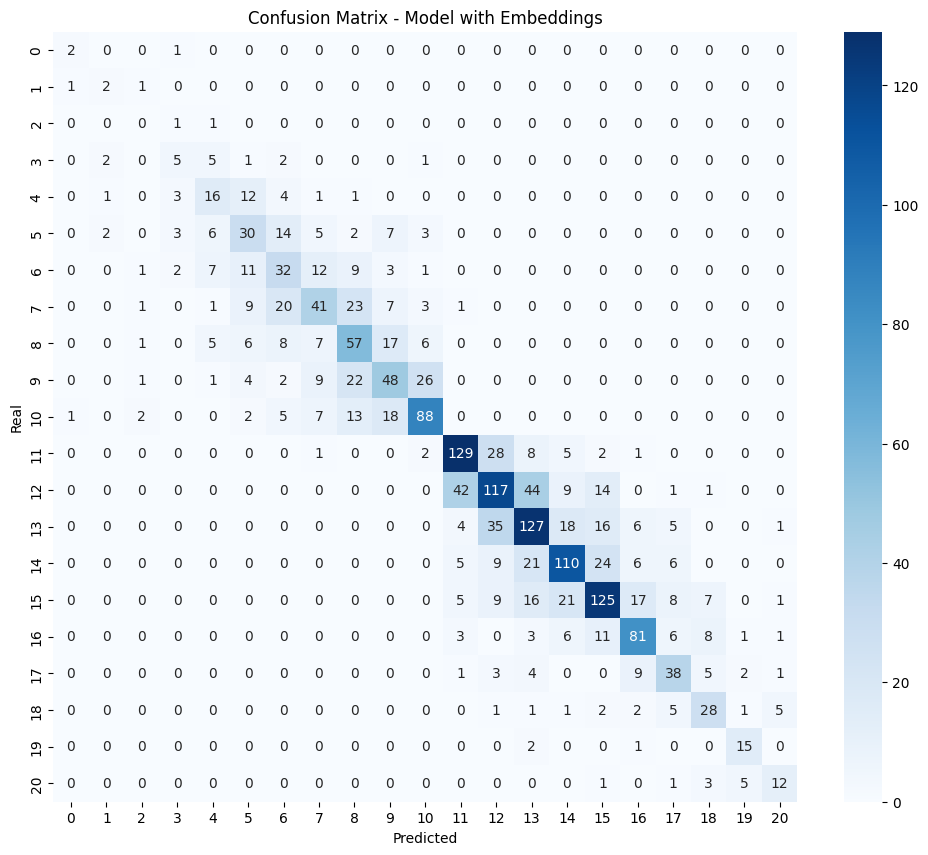

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_select(df_emb)

y_pred, _, _, _, _, _ = run_pipeline(make_pipeline(clf1), X_train, X_test, y_train, y_test, exp_name="Error Proximity Analysis - Random Forest with Embeddings", top_k=False)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix - Model with Embeddings')
plt.show()



Wow! Those results are revealing... What this shows is that despite it does not have a great precission, our model gets really close to the real class. This gives us the oportunity to merge some classes into the closest one in order to see if this assertion is true.

This assumption is based on MAE and top-k accuracy (and obviously in the confusion matrix).
- MAE: This one shows the mean error for each prediction, where a misclassification like real=18 predicted=17 the error would be |real-predicted|=1. So this awards the model for predicting in the correct zone, unlike accuracy, which is a binary rating and penalizes the same for big and low errors.
- top-k-accuracy: This metric shows the number of times where the predicted label is in the specified range ((real-k) <= real <= (real+k)), being more flexible than accuracy.

We will now merge the ratings into 6 classes to reinforce and prove our conclusions.

Experiment name is Error Proximity Analysis - Grouped Ratings
Accuracy: 0.8130
F1: 0.8122
MAE: 0.1901
Top-2 Accuracy: 0.9749


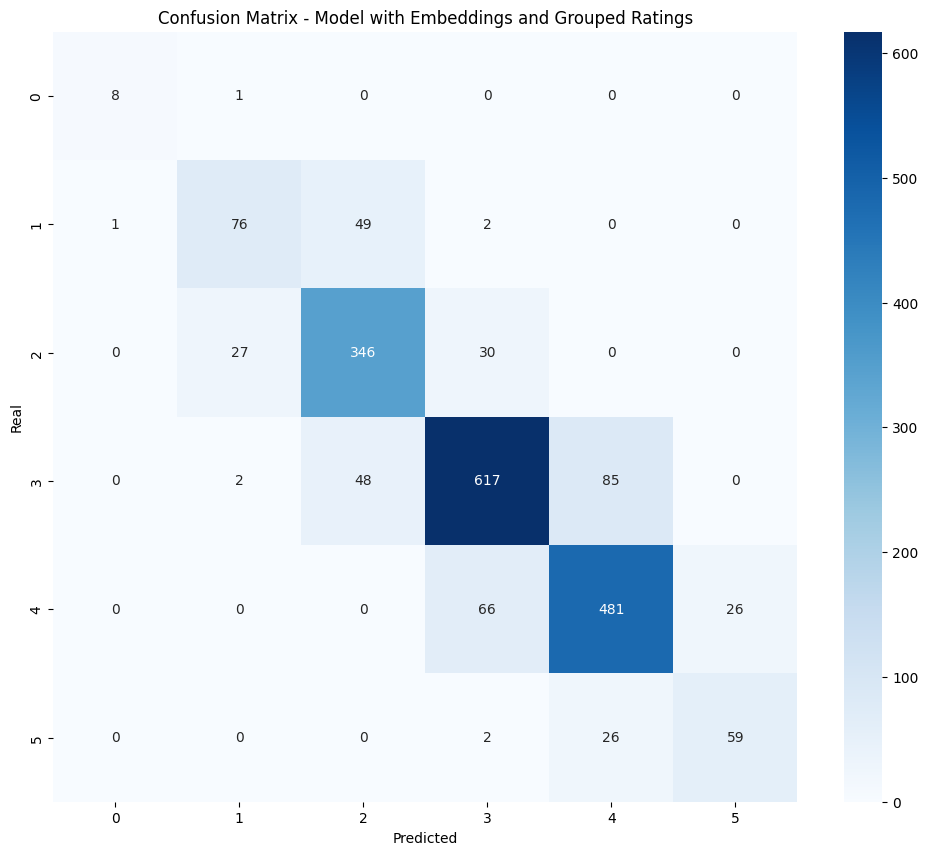

In [ ]:
# We create a dictionary to merge the ratings into 6 classes.
def group_ratings(rating_int):
    if rating_int >= 20: return 6
    if rating_int >= 16: return 5
    if rating_int >= 12:  return 4
    if rating_int >= 8:  return 3
    if rating_int >= 4:  return 2
    return 1

# We create a new dataframe with the grouped ratings and we run the same pipeline as before to see if the results improve.
df_emb_grouped = df_emb.copy()
df_emb_grouped['Rating'] = df_emb_grouped['Rating'].apply(group_ratings)
X_train, X_test, y_train, y_test = train_test_select(df_emb_grouped)
model = make_pipeline(clf1)

# We run the pipeline with the grouped ratings and we save the results in the comparisons_models dataframe.
y_pred, acc, f1, prec, rec, mae, tk_acc = run_pipeline(model, X_train, X_test, y_train, y_test, exp_name="Error Proximity Analysis - Grouped Ratings", top_k=True)
result = []
result.append({'Model': clf1.__class__.__name__, 'Accuracy': acc, 'F1 Score': f1, 'Precision': prec, 'Recall': rec, 'MAE': mae, 'Top-K Accuracy': tk_acc})
comparisons_models = pd.concat([comparisons_models, pd.DataFrame(result)]).reset_index(drop=True)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix - Model with Embeddings and Grouped Ratings')
plt.show()

Alright, it seems that our hypothesis was indeed correct. The model shows an incredible accuracy and f1 score, showcasing that the previous model was close whenever it made a prediction.

### 3.2 Optuna for hyperparameter tuning:
Compared to other frameworks such as Scikit-Learn, Optuna offers more advanced tools and more customization for optimizing processes. However, the main advantage this framework offers is the possibility of directly pruning those runs that do not look great, saving us so much time in the training process. The heuristics that decide whether to stop a training process are based on the intermediate training values such as poor evaluation metrics or bad performance on the training set.

In [21]:
import optuna
from sklearn.model_selection import cross_val_score
import sklearn.ensemble
import sklearn.linear_model
import sklearn.svm

classifiers = ["LogisticRegression", "RandomForestClassifier", "SVC"]

X_train, X_test, y_train, y_test = train_test_select(df_emb)

def objective(trial):
  classifier = trial.suggest_categorical("classifier", classifiers)

  if classifier == "LogisticRegression":
    lr_c = trial.suggest_float("lr_c", 1e-4, 1e4, log=True)
    lr_solver = trial.suggest_categorical("lr_solver", ['saga', 'lbfgs'])
    lr_penalty = trial.suggest_categorical("lr_penalty", ['l1', 'l2'])
    if lr_solver == 'lbfgs' and lr_penalty == 'l1':
        raise optuna.TrialPruned()

    lr_max_iter = trial.suggest_int("lr_max_iter", 100, 1000, step=500)

    obj_classifier = sklearn.linear_model.LogisticRegression(
        C=lr_c, solver=lr_solver, penalty=lr_penalty, max_iter=lr_max_iter, random_state=42)

  elif classifier == "RandomForestClassifier":
    rf_estimators = trial.suggest_int("rf_estimators", 100, 500, step=200)
    rf_max_features = trial.suggest_categorical("rf_max_features", ['sqrt', 'log2'])
    rf_max_depth = trial.suggest_int("rf_max_depth", 10, 50, step=20)
    rf_min_samples_split = trial.suggest_int("rf_min_samples_split", 2, 10, step=4)
    rf_min_samples_leaf = trial.suggest_int("rf_min_samples_leaf", 1, 4, step=2)
    rf_criterion = trial.suggest_categorical("rf_criterion", ['gini', 'entropy'])

    obj_classifier = sklearn.ensemble.RandomForestClassifier(
        n_estimators=rf_estimators, max_features=rf_max_features, max_depth=rf_max_depth,
        min_samples_split = rf_min_samples_split, min_samples_leaf = rf_min_samples_leaf,
        criterion = rf_criterion, random_state=42)

  elif classifier == "SVC":
    svc_c = trial.suggest_float("svc_c", 1e-2, 1e2, log=True)
    svc_kernel = trial.suggest_categorical("svc_kernel", ['linear', 'rbf', 'sigmoid'])
    svc_gamma = trial.suggest_categorical("svc_gamma", ['scale', 'auto'])

    obj_classifier = sklearn.svm.SVC(C=svc_c, kernel=svc_kernel, gamma=svc_gamma)

  score = sklearn.model_selection.cross_val_score(obj_classifier, X_train, y_train, n_jobs=-1, cv=3)
  accuracy = score.mean()
  return accuracy

When it comes to the hyperparameters we will try for our project, we have wanted to go further and try many more apart from the standard ones we have been able to find in the notebook. Let's list them down and describe what they are and the values used for each!



*   Logistic Regression:


    1. ``C``: is the inverse of the regularization strength (which must be a non-negative positive float). A regularization hyperparameter, whose smaller values indicate smaller penalization. We will use values ranging from 1e-4 up to 1e4.
    2. ``solver``: refers to the optimization algorithm used. We have not chosen all that are offered, just *liblinear* (great for multiclass n_classes > 3), *lbfgs* (works great for the majority of problems), *saga* (fast algorithm for large dataset as ours).
    3. ``penalty``: specifies the norm of the penaly. *l1* and *l2* being the L1/L2 penalties applied. Both of them being regularization methods already seen in class.
    (When it comes to using the *lbfgs*, there was no other compatible option than using the *l1* regularization.)


*   Random Forest:
    1. ``n_estimators``: refers to the number of trees used in the ensemble learning, going from 100 to 500 stepping by 100.
    2. ``max_features``: number of features to consider when looking for the best split.
    3. ``max_depth``: maximum depth level of the tree.
    4. ``min_samples_split``: number of minimum samples required to make a split in the tree.
    5. ``min_samples_leaf``: number of minimum samples required to create an end leaf node.
    6. ``criterion``: quality measure function for a split. *gini* (impurity measure) and *entropy* (Shannon information gain).

*   Support Vector Classifier:
    1. ``C``: Same as in the Logistic Regression.
    2. ``kernel``: specification of the kernel used in the algorithm. We are trying *linear*, *rbf* (default one), *poly* and *sigmoid*.
    3. ``gamma``: is the coefficient of the kernel, we are using *scale* (1 / (n_features * X.var())) and *auto* (1/n_features).


Running time! We will use the studied pruner ``M̀edianPruner`` which compares the intermediate result of a run to the best trial's intermediate result to decide whether to prune or not.

In [22]:
study_corporate_optuna = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=30, interval_steps=10))
study_corporate_optuna.optimize(objective, n_trials=10)

[I 2026-03-22 16:50:09,037] A new study created in memory with name: no-name-9be0e732-38d8-41bc-9c70-15ae78412ffc
[I 2026-03-22 16:50:17,515] Trial 0 finished with value: 0.1272023786030969 and parameters: {'classifier': 'SVC', 'svc_c': 11.81438525140988, 'svc_kernel': 'rbf', 'svc_gamma': 'scale'}. Best is trial 0 with value: 0.1272023786030969.
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multiclass-Corporate-Credit-Rating\.venv\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [100, 1000] and step=500, but the range is not divisible by `step`. It will be replaced with [100, 600].
  optuna_warn(
[I 2026-03-22 16:50:26,434] Trial 1 finished with value: 0.11779786259006371 and parameters: {'classifier': 'LogisticRegression', 'lr_c': 0.002307223453691171, 'lr_solver': 'saga', 'lr_penalty': 'l2', 'lr_max_iter': 600}. Best is trial 0 with value: 0.1272023786030969.
c:\Users\diego\Carrera\4\2do cuatri\ML Avanzado\Multiclass-Corporate-Credit-Rati

KeyboardInterrupt: 

Let's now run the model with the best hyperparameters obtained in the optuna study.

In [ ]:
print("Best trial:")
trial = study_corporate_optuna.best_trial

print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"\n{key}: {value}")


## **4. Results Discussion**
*    Present the results obtained from your models, focusing on the metrics chosen to evaluate their performance. Use tables to compare them.
*   Highlight any interesting findings or patterns observed during your analysis.


#### **Imbalance mitigation analisys**
To begin with this we will first talk about the oversampling techniques that we have used in this notebook. We have used RandomOverSampler, SMOTE, SMOTEENN and SMOTETomek.
- RandomOverSampler is a simple technique that randomly duplicates (this means with replacement) examples from the minority class.
- SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples from the minority class by interpolating between existing minority instances and their nearest neighbors, increasing the minority class population without duplicating samples.
- SMOTEENN combines SMOTE with Edited Nearest Neighbors (ENN) to remove noisy samples after oversampling from both the majority and minority classes, particularly those misclassified by their k-nearest neighbors.
- SMOTETomek combines SMOTE with Tomek links to remove random majority class data which nearest neighbors is the data from the minority class.

As some of the classes where significantly under sampled, we decided to remove those ones which precence was insignificant (classes with less than 6 samples) and in fact couldn't be oversampled due to the need of more samples of the previously mentioned methods. Moreover, this deletion was unimportant for the model and even further results showed that the models could estimate really well the range in which the corporations credit rating was located.

In [23]:
comparisons_data_augmentation.head(20)

,Model,Accuracy,F1 Score,Precision,Recall,MAE
0,RandomOverSampler + VotingClassifier,0.255897,0.301382,0.434219,0.255897,4.568718
1,RandomOverSampler + VotingClassifier,0.274872,0.322564,0.452767,0.274872,4.406667
2,SMOTE + VotingClassifier,0.233846,0.275284,0.424078,0.233846,4.718462
3,SMOTE + VotingClassifier,0.304103,0.337565,0.441823,0.304103,3.375897
4,SMOTEENN + VotingClassifier,0.189231,0.215840,0.340046,0.189231,4.974359
5,SMOTEENN + VotingClassifier,0.240513,0.266401,0.343149,0.240513,3.783077
6,SMOTETomek + VotingClassifier,0.233333,0.271974,0.402983,0.233333,4.560513
7,SMOTETomek + VotingClassifier,0.301538,0.332264,0.435108,0.301538,3.323077
8,VotingClassifier + class_weight='balanced',0.234872,0.280594,0.422546,0.234872,4.812821
9,VotingClassifier + class_weight='balanced',0.259487,0.299643,0.426887,0.259487,4.402051


For evaluating the over sampling methods we tried with a voting classifier in order to test 3 different models ensembled. The models were SVC, RandomForestClassifier and LogisticRegressor. In the upper table we can see that the oversamplings improved some results. For instance, the accuracy, f1-score and even the mae were better in voting classifiers whenever they had a data augmentation method, being SMOTE the best among the 4 that we tried.

However, the results for RandomForestClassifier on its own were different. It had a much better performance over the ensembled models in VotingClassifier. In fact, it performed better when there were no oversampling methods, showcasing that those methods were benefitting some of the models like SVC or LogisticRegression while they were handicapping RandomForestClassifier.

Finally, for this part we can mention that those models trained with word embeddings made it better than those without them, evidencing that the intrinsic meaning of some corporation names can also provide valuable information in rating them.

#### Model Comparison

To follow, the model comparison revealed us some important clues about their performance. At a first glance, we can see that the models don't guess much (recall) and when they do it is without high precision (precision). This led us to a question: Are really the models that bad? To try this out, we primarily made a confusion matrix to compare the real values with the predicted ones.

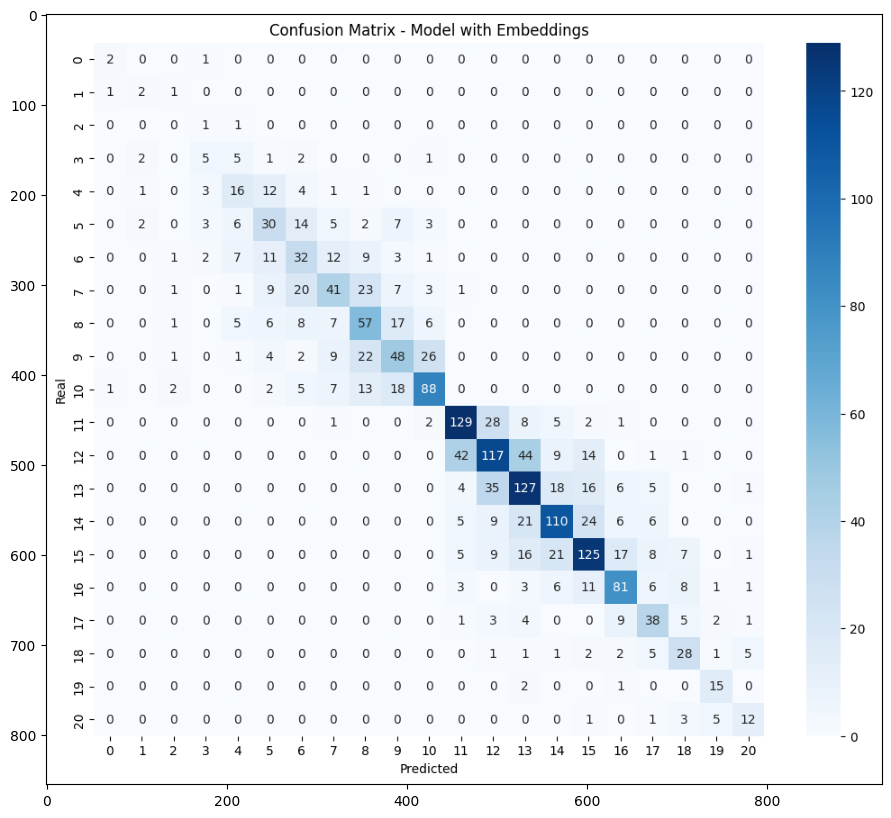

In [ ]:
img = plt.imread('../img/confusion_mat.png')
plt.figure(figsize=(12,10))
plt.imshow(img)

After doing this we were prety confident in the fact that the problems were not the models, but the metrics we were using to evaluate them. In this case, we were focusing solely on accuracy or the F1 score, ignoring the possibility of having a model that, although it does not always get the correct result, stays close to the correct answer.

To prove this further, we extracted some metrics like MAE and top-k (which have already been explained).

In [42]:
comparisons_models.head(8)

,Model,Accuracy,F1 Score,Precision,Recall,MAE,Top-K Accuracy
0,RandomForestClassifier,0.537949,0.537645,0.539322,0.537949,0.842564,0.717949
1,RandomForestClassifier,0.565641,0.565890,0.569345,0.565641,0.772308,0.765128
2,DecisionTreeClassifier,0.517949,0.518504,0.524231,0.517949,0.995897,0.583590
3,DecisionTreeClassifier,0.523077,0.524747,0.531054,0.523077,0.929744,0.592308
4,HistGradientBoostingClassifier,0.116410,0.081479,0.166575,0.116410,3.494872,0.136923
5,HistGradientBoostingClassifier,0.111795,0.066357,0.091082,0.111795,3.060513,0.136923
6,AdaBoostClassifier,0.526667,0.526740,0.528859,0.526667,0.842051,0.637436
7,AdaBoostClassifier,0.547692,0.548183,0.550553,0.547692,0.785641,0.655897


The MAE and top-2 accuracy confirmed our hypothesys. The models weren't precise, but they estimated quite good the rating that more or less the companies should have. To be more specific, the MAE in RandomForestClassifier with word embeddings was the best, with a value of 0.77. Showing that the mean error of each prediction was 0.77 classes far (not even a complete class). And the top-2 accuracy was also the best in the same model, showcasing an excelent accuracy (77%) on a range of +-2 from the real label.

Finally, looking at other ratings and datasets, the amount of classes that this one has is somehow big. For that reason, we decided to merge some of the classes in one in the following manner:
```
    if rating_int >= 20: return 6
    if rating_int >= 16: return 5
    if rating_int >= 12:  return 4
    if rating_int >= 8:  return 3
    if rating_int >= 4:  return 2
    return 1
```

This means that those classes with highest ratings (AAA, AA+, AA...) were assigned to a higher number (6) and those with the lowest ratings (CC, C...) were assigned to a lower number (1).

In [50]:
comparisons_models.head(9).tail(1)

,Model,Accuracy,F1 Score,Precision,Recall,MAE,Top-K Accuracy
8,RandomForestClassifier,0.813012,0.812156,0.81332,0.813012,0.190061,0.974898


This final step confirms that we have developed a solid model. While it is true that we adapted it, this process highlighted the importance of carefully selecting the evaluation metrics and determining how relevant is to have an error free model for our use case. In this example, failing to get the exact class was not really harmful as long as we are close to the target. However, this tolerance could disapear in other fields such as medicine, where even a slight deviation can have big consequences.

### **Useful links**
*[SMOTE vs SMOTEENN](https://www.mdpi.com/1999-4893/18/1/37)*<p>
*[Imbalanced Classification in Python: SMOTE-Tomek Links Method](https://towardsdatascience.com/imbalanced-classification-in-python-smote-tomek-links-method-6e48dfe69bbc/)*

## **5. Lessons Learned**


*   Identify key challenges you faced during the project and how you overcame them.
*   Share any insights gained from working with an imbalanced dataset and the impact of various preprocessing and modeling techniques on your results.

